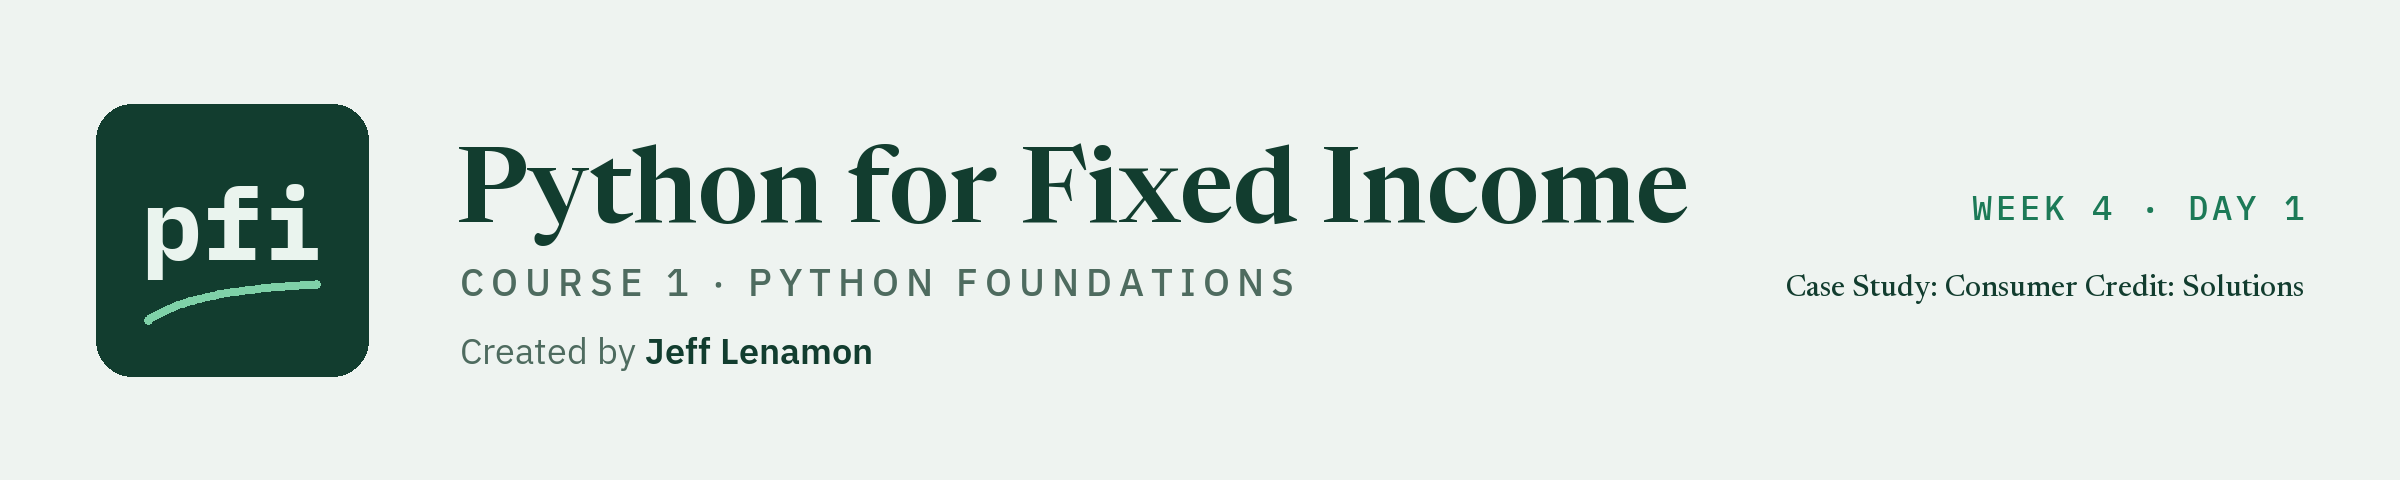

# Case Study: Consumer Credit - Solutions

Week 4. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week4/day1/16_case_study_consumer_credit_solutions.ipynb)

## Exercises

The exercises use the same file and ask about columns and groupings the lesson did not examine: the August repayment status, the credit limit by outcome and education, sex and marital status together, and the months with no payment. The data is the UCI "Default of Credit Card Clients" dataset by I-Cheng Yeh, CC BY 4.0, as described at the top of this notebook.

Every answer is a rate or a figure in this file, with its count. None is a statement of cause or a statement about people in general.

Replace each `...` with your own code, then run the check cell. Print the numbers you rely on and say the unit. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports the libraries, defines `check`, a small function that marks your answers, and loads `raw` and the working copy `cards`, with the outcome column renamed `default` and the three label columns `sex`, `education`, and `marriage`. It prints the two shapes, (30000, 25) and (30000, 28).

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# a fresh copy of the file. In Colab it is read from GitHub.
if os.path.exists('../../../data/credit_card_default.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

raw = pd.read_csv(data_folder + 'credit_card_default.csv')

# the working copy of the lesson: the outcome renamed, and the three labels added
cards = raw.copy().rename(columns={'default payment next month': 'default'})
cards['sex'] = cards['SEX'].map({1: 'male', 2: 'female'})
cards['education'] = cards['EDUCATION'].map({1: 'graduate school', 2: 'university', 3: 'high school', 4: 'others'}).fillna('not documented')
cards['marriage'] = cards['MARRIAGE'].map({1: 'married', 2: 'single', 3: 'others'}).fillna('not documented')

print(raw.shape, cards.shape)

(30000, 25) (30000, 28)


### Exercise 1

Q. `PAY_2` is the repayment status in August 2005. Among the accounts with a `PAY_2` of 2, a payment delay of two months, how many accounts are there and what was the default rate in percent, rounded to 2 decimal places? Store the answers in **ex1_accounts** and **ex1_rate**. Print the rate table for every value of `PAY_2`, and say which values are not in the documentation.

In [2]:
# accounts, defaults, and rate for each value of the August status
by_august = cards.groupby('PAY_2')['default'].agg(['count', 'sum', 'mean'])
by_august.columns = ['accounts', 'defaults', 'rate_pct']
by_august['rate_pct'] = (by_august['rate_pct'] * 100).round(2)
print(by_august)

ex1_accounts = by_august.loc[2, 'accounts']
ex1_rate = by_august.loc[2, 'rate_pct']

print('Accounts with an August status of 2:', ex1_accounts)
print('Their default rate:', ex1_rate, 'percent')

       accounts  defaults  rate_pct
PAY_2                              
-2         3782       691     18.27
-1         6050       966     15.97
 0        15730      2503     15.91
 1           28         5     17.86
 2         3927      2184     55.61
 3          326       201     61.66
 4           99        50     50.51
 5           25        15     60.00
 6           12         9     75.00
 7           20        12     60.00
 8            1         0      0.00
Accounts with an August status of 2: 3927
Their default rate: 55.61 percent


* 3,927 accounts had an August status of 2, and 55.61 percent of them defaulted. In the lesson the September status of 2 had 2,667 accounts and a rate of 69.14 percent.
* The values -2 and 0 are not in the documentation. In August they are on 3,782 and 15,730 accounts, with default rates of 18.27 and 15.91 percent.
* The value 1 is on only 28 accounts in August, against 3,688 in September. The documentation does not say why. The value 8 is on 1 account, whose rate of 0.0 percent is one account that did not default.

In [3]:
check('Exercise 1 accounts', ex1_accounts, 3927)
check('Exercise 1 rate', ex1_rate, 55.61)

Exercise 1 accounts: correct
Exercise 1 rate: correct


### Exercise 2

Q. What is the median credit limit, in NT dollars, for each education label? Store the median for `graduate school` in **ex2_graduate** and for `high school` in **ex2_high_school**. Show the number of accounts beside each median.

In [4]:
# the number of accounts and the median limit for each education label
limit_by_education = cards.groupby('education')['LIMIT_BAL'].agg(['count', 'median'])
print(limit_by_education)

ex2_graduate = limit_by_education.loc['graduate school', 'median']
ex2_high_school = limit_by_education.loc['high school', 'median']

print('Median limit, graduate school:', ex2_graduate, 'NT dollars')
print('Median limit, high school:', ex2_high_school, 'NT dollars')

                 count    median
education                       
graduate school  10585  200000.0
high school       4917   80000.0
not documented     345  150000.0
others             123  200000.0
university       14030  110000.0
Median limit, graduate school: 200000.0 NT dollars
Median limit, high school: 80000.0 NT dollars


* The median credit limit is 200,000 NT dollars for the 10,585 accounts labelled graduate school, 110,000 for the 14,030 labelled university, and 80,000 for the 4,917 labelled high school. The two small groups: 200,000 for `others` (123 accounts) and 150,000 for `not documented` (345 accounts).
* The lesson found that the default rate differed across the limit bands and across the education labels. This table shows that the two columns are themselves related, so those two findings are not independent of each other. That is a reason to be careful with each one. It is not an explanation of either.

In [5]:
check('Exercise 2 graduate school', ex2_graduate, 200000.0)
check('Exercise 2 high school', ex2_high_school, 80000.0)

Exercise 2 graduate school: correct
Exercise 2 high school: correct


### Exercise 3

Q. Build a pivot table of the default rate with `marriage` down the side and `sex` across the top, and a second one of the counts. What was the default rate, in percent rounded to 2 decimal places, for the accounts labelled `married` and `male`, and how many accounts is that? Store the answers in **ex3_rate** and **ex3_accounts**. Which cell is the thinnest?

In [6]:
# the default rate of each combination, in percent
rates = pd.pivot_table(cards, values='default', index='marriage', columns='sex', aggfunc='mean')
rates = (rates * 100).round(2)
print(rates)

# the number of accounts in each combination
counts = pd.pivot_table(cards, values='default', index='marriage', columns='sex', aggfunc='count')
print(counts)

ex3_rate = rates.loc['married', 'male']
ex3_accounts = counts.loc['married', 'male']

print('Married and male:', ex3_rate, 'percent of', ex3_accounts, 'accounts')
print('Accounts in the count table:', counts.sum().sum())

sex             female   male
marriage                     
married          21.96  25.93
not documented    7.50  14.29
others           22.92  30.53
single           19.72  22.66
sex             female  male
marriage                    
married           8469  5190
not documented      40    14
others             192   131
single            9411  6553
Married and male: 25.93 percent of 5190 accounts
Accounts in the count table: 30000


* 25.93 percent of the 5,190 accounts labelled married and male defaulted.
* The thinnest cell is `not documented` and male, with 14 accounts. Its rate of 14.29 percent is 2 defaults in 14.
* The eight counts add up to 30,000. As in the lesson, these are rates in this file. They do not explain themselves and are not a basis for treating people differently.

In [7]:
check('Exercise 3 rate', ex3_rate, 25.93)
check('Exercise 3 accounts', ex3_accounts, 5190)

Exercise 3 rate: correct
Exercise 3 accounts: correct


### Exercise 4

Q. Build a derived column: for each account, the number of the six months, April to September, in which the amount paid (`PAY_AMT1` to `PAY_AMT6`) was zero. How many accounts paid nothing in all six months, and what was their default rate in percent, rounded to 2 decimal places? Store the answers in **ex4_accounts** and **ex4_rate**. Print the rate table for every count from 0 to 6.

In [8]:
# the six payment columns, September back to April
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# True for each month with a payment of zero, added across the six columns of a row
cards['months_unpaid'] = (cards[payment_columns] == 0).sum(axis=1)

by_unpaid = cards.groupby('months_unpaid')['default'].agg(['count', 'sum', 'mean'])
by_unpaid.columns = ['accounts', 'defaults', 'rate_pct']
by_unpaid['rate_pct'] = (by_unpaid['rate_pct'] * 100).round(2)
print(by_unpaid)

ex4_accounts = by_unpaid.loc[6, 'accounts']
ex4_rate = by_unpaid.loc[6, 'rate_pct']

print('Accounts with no payment in all six months:', ex4_accounts)
print('Their default rate:', ex4_rate, 'percent')

               accounts  defaults  rate_pct
months_unpaid                              
0                 15458      2151     13.92
1                  5473      1586     28.98
2                  3387      1141     33.69
3                  1944       608     31.28
4                  1304       328     25.15
5                  1002       278     27.74
6                  1432       544     37.99
Accounts with no payment in all six months: 1432
Their default rate: 37.99 percent


* 1,432 accounts paid nothing in all six months, and 37.99 percent of them defaulted.
* 15,458 accounts made a payment in every month, and 13.92 percent of them defaulted.
* The rates do not rise step by step in between: 28.98 percent with one month of no payment, 33.69 with two, 31.28 with three, 25.15 with four, and 27.74 with five. The column counts payments of zero. The documentation does not say which of them were payments that were due and not made, and section 3.3 found 2,008 accounts whose September bill was itself zero.

In [9]:
check('Exercise 4 accounts', ex4_accounts, 1432)
check('Exercise 4 rate', ex4_rate, 37.99)

Exercise 4 accounts: correct
Exercise 4 rate: correct


### Exercise 5: AI check

You ask an AI assistant for the default rate by education level, with the number of accounts in each level, and the default rate of all the accounts in the table. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it misleads in one way.

Q. Read the code before you run it. How many accounts should the table hold in total, and what should the overall default rate be? The lesson worked both out in section 2.1. Then run the code. Does the answer agree with you?

* The lesson's file has 30,000 accounts and a default rate of 22.12 percent. The original code reported 29,655 accounts and 22.29 percent, with no error and no warning.
* The problem was the line `known = cards[cards['EDUCATION'].isin([1, 2, 3, 4])]`. It keeps the four documented codes and silently drops the 345 accounts with codes 0, 5, and 6. The comment calls it "clean up", and nothing in the output says that rows were removed.
* Two numbers give it away. The accounts add up to 29,655, which is 345 short of 30,000. And the overall rate is 22.29 percent against the lesson's 22.12: the dropped accounts had 26 defaults in 345, a rate of 7.54 percent, so leaving them out pushes the rate of the rest up.
* The four rates it printed for codes 1 to 4 are correct. The table is wrong by what it leaves out. The fix is to keep every account and show the undocumented codes as a group of their own.

In [10]:
# default rate by education label, in percent, with every account kept
by_level = cards.groupby('education')['default'].agg(['count', 'mean'])
by_level['mean'] = (by_level['mean'] * 100).round(2)
print(by_level)

ex5_accounts = by_level['count'].sum()
ex5_overall_rate = round(cards['default'].mean() * 100, 2)

print('Accounts in the table:', ex5_accounts)
print('Overall default rate:', ex5_overall_rate, 'percent')

                 count   mean
education                    
graduate school  10585  19.23
high school       4917  25.16
not documented     345   7.54
others             123   5.69
university       14030  23.73
Accounts in the table: 30000
Overall default rate: 22.12 percent


In [11]:
check('Exercise 5 accounts', ex5_accounts, 30000)
check('Exercise 5 overall rate', ex5_overall_rate, 22.12)

Exercise 5 accounts: correct
Exercise 5 overall rate: correct
